# Texas Salary Prediction

* The Texas state government employs a workforce across multiple agencies, roles, and employment statuses. Accurately predicting employee salaries is essential for budgeting, equity analysis, and operational efficiency. The dataset includes key attributes such as agency, class title, ethnicity, gender, hours worked, and multiple-job roles, offering a rich basis for building predictive models.

## Domain Analysis :-

In [49]:
import pandas as pd # for data manipulation and analysis
import numpy as np  # for numerical operations
import matplotlib.pyplot as plt # for visualizing data
import seaborn as sns # for statistical data visualization
import warnings # to handle warning messages
warnings.filterwarnings("ignore") # suppress warnings from output

In [50]:
data = pd.read_csv('salary.csv') # load the dataset from CSV file
data # display the DataFrame

,AGENCY,AGENCY NAME,LAST NAME,FIRST NAME,MI,CLASS CODE,CLASS TITLE,ETHNICITY,GENDER,STATUS,EMPLOY DATE,HRLY RATE,HRS PER WK,MONTHLY,ANNUAL,STATE NUMBER,duplicated,multiple_full_time_jobs,combined_multiple_jobs,summed_annual_salary,hide_from_search
0,241,"COMPTROLLER OF PUBLIC ACCOUNTS, JUDICIARY SECT...",RUCKER,MORTON,V,JD25,"JUDGE, RETIRED ...",WHITE,MALE,URP - UNCLASSIFIED REGULAR PART-TIME,02/18/88,75.96150,29.0,9545.82,114549.84,127717,True,NaN,NaN,131407.08,NaN
1,212,OFFICE OF COURT ADMINISTRATION ...,RUCKER,MORTON,V,3524,GENERAL COUNSEL IV ...,WHITE,MALE,CTP - CLASSIFIED TEMPORARY PART-TIME,02/01/15,81.04454,4.0,1404.77,16857.24,127717,True,NaN,NaN,NaN,True
2,241,"COMPTROLLER OF PUBLIC ACCOUNTS, JUDICIARY SECT...",SPECIA JR,JOHN,J,JD25,"JUDGE, RETIRED ...",WHITE,MALE,URP - UNCLASSIFIED REGULAR PART-TIME,02/01/20,75.96150,29.0,9545.82,114549.84,59115,True,NaN,NaN,131407.08,NaN
3,212,OFFICE OF COURT ADMINISTRATION ...,SPECIA JR,JOHN,J,3524,GENERAL COUNSEL IV ...,WHITE,MALE,CTP - CLASSIFIED TEMPORARY PART-TIME,09/01/18,81.04453,4.0,1404.77,16857.24,59115,True,NaN,NaN,NaN,True
4,696,TEXAS DEPARTMENT OF CRIMINAL JUSTICE ...,ONTIVEROS,ESTHER,,4504,CORREC OFFICER IV ...,HISPANIC,FEMALE,CRF - CLASSIFIED REGULAR FULL-TIME,06/29/20,0.00000,40.0,3284.27,39411.24,165030,True,1.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149476,809,STATE PRESERVATION BOARD ...,WESSELS,JOHN,P,6232,SECURITY OFFICER III ...,WHITE,MALE,CRF - CLASSIFIED REGULAR FULL-TIME,10/30/17,0.00000,40.0,2899.00,34788.00,770781,NaN,NaN,NaN,NaN,NaN
149477,809,STATE PRESERVATION BOARD ...,WINDHAM,EVAN,A,0302,WEB ADMINISTRATOR III ...,WHITE,FEMALE,CRF - CLASSIFIED REGULAR FULL-TIME,07/13/15,0.00000,40.0,5500.00,66000.00,847431,NaN,NaN,NaN,NaN,NaN
149478,809,STATE PRESERVATION BOARD ...,WRIGHT,DERRICK,C,0130,CUSTOMER SERVICE REP I ...,WHITE,MALE,CRP - CLASSIFIED REGULAR PART-TIME,10/15/12,12.93000,20.0,1120.60,13447.20,34266,NaN,NaN,NaN,NaN,NaN
149479,809,STATE PRESERVATION BOARD ...,YOUNG,DOUGLAS,R,1572,PROGRAM SPECIALIST III ...,WHITE,MALE,CRF - CLASSIFIED REGULAR FULL-TIME,09/22/89,0.00000,40.0,5744.16,68929.92,123490,NaN,NaN,NaN,NaN,NaN


In [51]:
pd.set_option('display.max_columns',None) #expand the all columns # configure pandas to display all columns

## Feature Information

* AGENCY: The name of the organization or government body that the employee works for.
* AGENCY NAME: The specific agency within the larger organization.
* LAST NAME: The employee's last name.
* FIRST NAME: The employee's first name.
* MI (Middle Initial): The employee's middle initial, if applicable.
* CLASS CODE: A code identifying the employee's job classification.
* CLASS TITLE: The title or description of the employee's job.
* ETHNICITY: The employee's ethnic background.
* GENDER: The employee's gender.
* STATUS: The employment status of the individual (e.g., full-time, part-time, contract).
* EMPLOY DATE: The date the employee was hired.
* HRLY RATE: The employee’s hourly pay rate.
* HRS PER WK: The number of hours the employee works per week.
* MONTHLY: The employee's monthly salary.
* ANNUAL: The employee's annual salary.
* STATE NUMBER: Likely refers to a state or employee identification number.
* duplicated: A flag that may indicate if the employee record is a duplicate.
* multiple_full_time_jobs: Whether the employee holds more than one full-time job.
* combined_multiple_jobs: The combined salary for employees holding multiple jobs.
* summed_annual_salary: The total salary after summing across jobs or positions.
* hide_from_search: Whether the record is hidden from search results for privacy or security reasons.

In [52]:
data.rename(columns={"AGENCY NAME":"AGENCY_NAME","LAST NAME":"LAST_NAME","FIRST NAME":"FIRST_NAME","CLASS CODE":"CLASS_CODE","CLASS TITLE":"CLASS_TITLE"
                     ,"EMPLOY DATE":"EMPLOY_DATE","HRLY RATE":"HRLY_RATE","HRS PER WK":"HRS_PER_WK","STATE NUMBER":"STATE_NUMBER"},inplace=True)

# Basic Check :-

In [53]:
## It show first five rows of the dataset.
data.head()

,AGENCY,AGENCY_NAME,LAST_NAME,FIRST_NAME,MI,CLASS_CODE,CLASS_TITLE,ETHNICITY,GENDER,STATUS,EMPLOY_DATE,HRLY_RATE,HRS_PER_WK,MONTHLY,ANNUAL,STATE_NUMBER,duplicated,multiple_full_time_jobs,combined_multiple_jobs,summed_annual_salary,hide_from_search
0,241,"COMPTROLLER OF PUBLIC ACCOUNTS, JUDICIARY SECT...",RUCKER,MORTON,V,JD25,"JUDGE, RETIRED ...",WHITE,MALE,URP - UNCLASSIFIED REGULAR PART-TIME,02/18/88,75.96150,29.0,9545.82,114549.84,127717,True,NaN,NaN,131407.08,NaN
1,212,OFFICE OF COURT ADMINISTRATION ...,RUCKER,MORTON,V,3524,GENERAL COUNSEL IV ...,WHITE,MALE,CTP - CLASSIFIED TEMPORARY PART-TIME,02/01/15,81.04454,4.0,1404.77,16857.24,127717,True,NaN,NaN,NaN,True
2,241,"COMPTROLLER OF PUBLIC ACCOUNTS, JUDICIARY SECT...",SPECIA JR,JOHN,J,JD25,"JUDGE, RETIRED ...",WHITE,MALE,URP - UNCLASSIFIED REGULAR PART-TIME,02/01/20,75.96150,29.0,9545.82,114549.84,59115,True,NaN,NaN,131407.08,NaN
3,212,OFFICE OF COURT ADMINISTRATION ...,SPECIA JR,JOHN,J,3524,GENERAL COUNSEL IV ...,WHITE,MALE,CTP - CLASSIFIED TEMPORARY PART-TIME,09/01/18,81.04453,4.0,1404.77,16857.24,59115,True,NaN,NaN,NaN,True
4,696,TEXAS DEPARTMENT OF CRIMINAL JUSTICE ...,ONTIVEROS,ESTHER,,4504,CORREC OFFICER IV ...,HISPANIC,FEMALE,CRF - CLASSIFIED REGULAR FULL-TIME,06/29/20,0.00000,40.0,3284.27,39411.24,165030,True,1.0,NaN,NaN,NaN


In [54]:
## It show last five rows of the dataset.
data.tail()

,AGENCY,AGENCY_NAME,LAST_NAME,FIRST_NAME,MI,CLASS_CODE,CLASS_TITLE,ETHNICITY,GENDER,STATUS,EMPLOY_DATE,HRLY_RATE,HRS_PER_WK,MONTHLY,ANNUAL,STATE_NUMBER,duplicated,multiple_full_time_jobs,combined_multiple_jobs,summed_annual_salary,hide_from_search
149476,809,STATE PRESERVATION BOARD ...,WESSELS,JOHN,P,6232,SECURITY OFFICER III ...,WHITE,MALE,CRF - CLASSIFIED REGULAR FULL-TIME,10/30/17,0.00,40.0,2899.00,34788.00,770781,NaN,NaN,NaN,NaN,NaN
149477,809,STATE PRESERVATION BOARD ...,WINDHAM,EVAN,A,0302,WEB ADMINISTRATOR III ...,WHITE,FEMALE,CRF - CLASSIFIED REGULAR FULL-TIME,07/13/15,0.00,40.0,5500.00,66000.00,847431,NaN,NaN,NaN,NaN,NaN
149478,809,STATE PRESERVATION BOARD ...,WRIGHT,DERRICK,C,0130,CUSTOMER SERVICE REP I ...,WHITE,MALE,CRP - CLASSIFIED REGULAR PART-TIME,10/15/12,12.93,20.0,1120.60,13447.20,34266,NaN,NaN,NaN,NaN,NaN
149479,809,STATE PRESERVATION BOARD ...,YOUNG,DOUGLAS,R,1572,PROGRAM SPECIALIST III ...,WHITE,MALE,CRF - CLASSIFIED REGULAR FULL-TIME,09/22/89,0.00,40.0,5744.16,68929.92,123490,NaN,NaN,NaN,NaN,NaN
149480,809,STATE PRESERVATION BOARD ...,ZUNKER,GEORGIA,P,0130,CUSTOMER SERVICE REP I ...,WHITE,FEMALE,CRP - CLASSIFIED REGULAR PART-TIME,02/16/12,11.74,20.0,1017.46,12209.52,103583,NaN,NaN,NaN,NaN,NaN


In [55]:
# Display summary information about the DataFrame.
data.info() # display info about DataFrame structure

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149481 entries, 0 to 149480
Data columns (total 21 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   AGENCY                   149481 non-null  int64  
 1   AGENCY_NAME              149481 non-null  object 
 2   LAST_NAME                149481 non-null  object 
 3   FIRST_NAME               149481 non-null  object 
 4   MI                       149481 non-null  object 
 5   CLASS_CODE               149481 non-null  object 
 6   CLASS_TITLE              149481 non-null  object 
 7   ETHNICITY                149481 non-null  object 
 8   GENDER                   149481 non-null  object 
 9   STATUS                   149481 non-null  object 
 10  EMPLOY_DATE              149481 non-null  object 
 11  HRLY_RATE                149481 non-null  float64
 12  HRS_PER_WK               149481 non-null  float64
 13  MONTHLY                  149481 non-null  float64
 14  ANNU

In [56]:
## It show the statistical information of data.
data.describe() # statistical summary of the dataset

,AGENCY,HRLY_RATE,HRS_PER_WK,MONTHLY,ANNUAL,STATE_NUMBER,multiple_full_time_jobs,summed_annual_salary
count,149481.000000,149481.000000,149481.000000,149481.000000,149481.000000,1.494810e+05,14.0,16.000000
mean,545.736288,0.346488,39.714918,4226.184248,50714.210973,5.651930e+05,1.0,74303.955000
std,139.057691,4.211485,2.323855,2093.111691,25117.340292,4.786212e+05,0.0,51925.944282
min,101.000000,0.000000,1.000000,50.000000,600.000000,1.000000e+00,1.0,18000.000000
25%,529.000000,0.000000,40.000000,3019.840000,36238.080000,1.133340e+05,1.0,32962.500000
50%,530.000000,0.000000,40.000000,3720.170000,44642.040000,3.463730e+05,1.0,48063.300000
75%,696.000000,0.000000,40.000000,4865.810000,58389.720000,1.100500e+06,1.0,123751.770000
max,930.000000,117.788480,70.000000,46125.000000,553500.000000,1.271604e+06,1.0,171383.400000


In [57]:
## It show the statistical information of data.
data.describe(include = "O")

,AGENCY_NAME,LAST_NAME,FIRST_NAME,MI,CLASS_CODE,CLASS_TITLE,ETHNICITY,GENDER,STATUS,EMPLOY_DATE,duplicated,combined_multiple_jobs,hide_from_search
count,149481,149481,149481,149481,149481,149481,149481,149481,149481,149481,143,97,16
unique,113,38675,23559,27,1481,1422,6,2,11,6295,1,1,1
top,HEALTH AND HUMAN SERVICES COMMISSION ...,SMITH,MICHAEL,,4504,CORREC OFFICER IV ...,WHITE,FEMALE,CRF - CLASSIFIED REGULAR FULL-TIME,09/01/17,True,True,True
freq,36667,1243,1843,38408,9267,9267,67142,85328,142502,12359,143,97,16


In [58]:
# Here,we are drop to not need of column
data.drop(columns=["AGENCY","LAST_NAME","FIRST_NAME","MI","EMPLOY_DATE","duplicated","multiple_full_time_jobs","combined_multiple_jobs",
                   "summed_annual_salary","hide_from_search"],axis=1,inplace=True)

* The dataset shows a diverse workforce with significant variation in hourly rates, most employees working close to 40 hours per week, and a wide salary range from 600 to 5,53,500 annually, indicating both low and high-paying positions, with many employees earning relatively low wages.

# Exploratory Data Analysis :-

* Exploratory Data Analysis (EDA): is an essential step in the data analysis process, where the primary goal is to explore and understand the underlying structure of a dataset. It is a crucial preliminary step before any statistical modeling or machine learning processes. Below is a more detailed explanation of EDA:

### 1. Univariate Analysis

(array([-250000.,       0.,  250000.,  500000.,  750000., 1000000.,
        1250000., 1500000.]),
 [Text(-250000.0, 0, '−0.25'),
  Text(0.0, 0, '0.00'),
  Text(250000.0, 0, '0.25'),
  Text(500000.0, 0, '0.50'),
  Text(750000.0, 0, '0.75'),
  Text(1000000.0, 0, '1.00'),
  Text(1250000.0, 0, '1.25'),
  Text(1500000.0, 0, '1.50')])

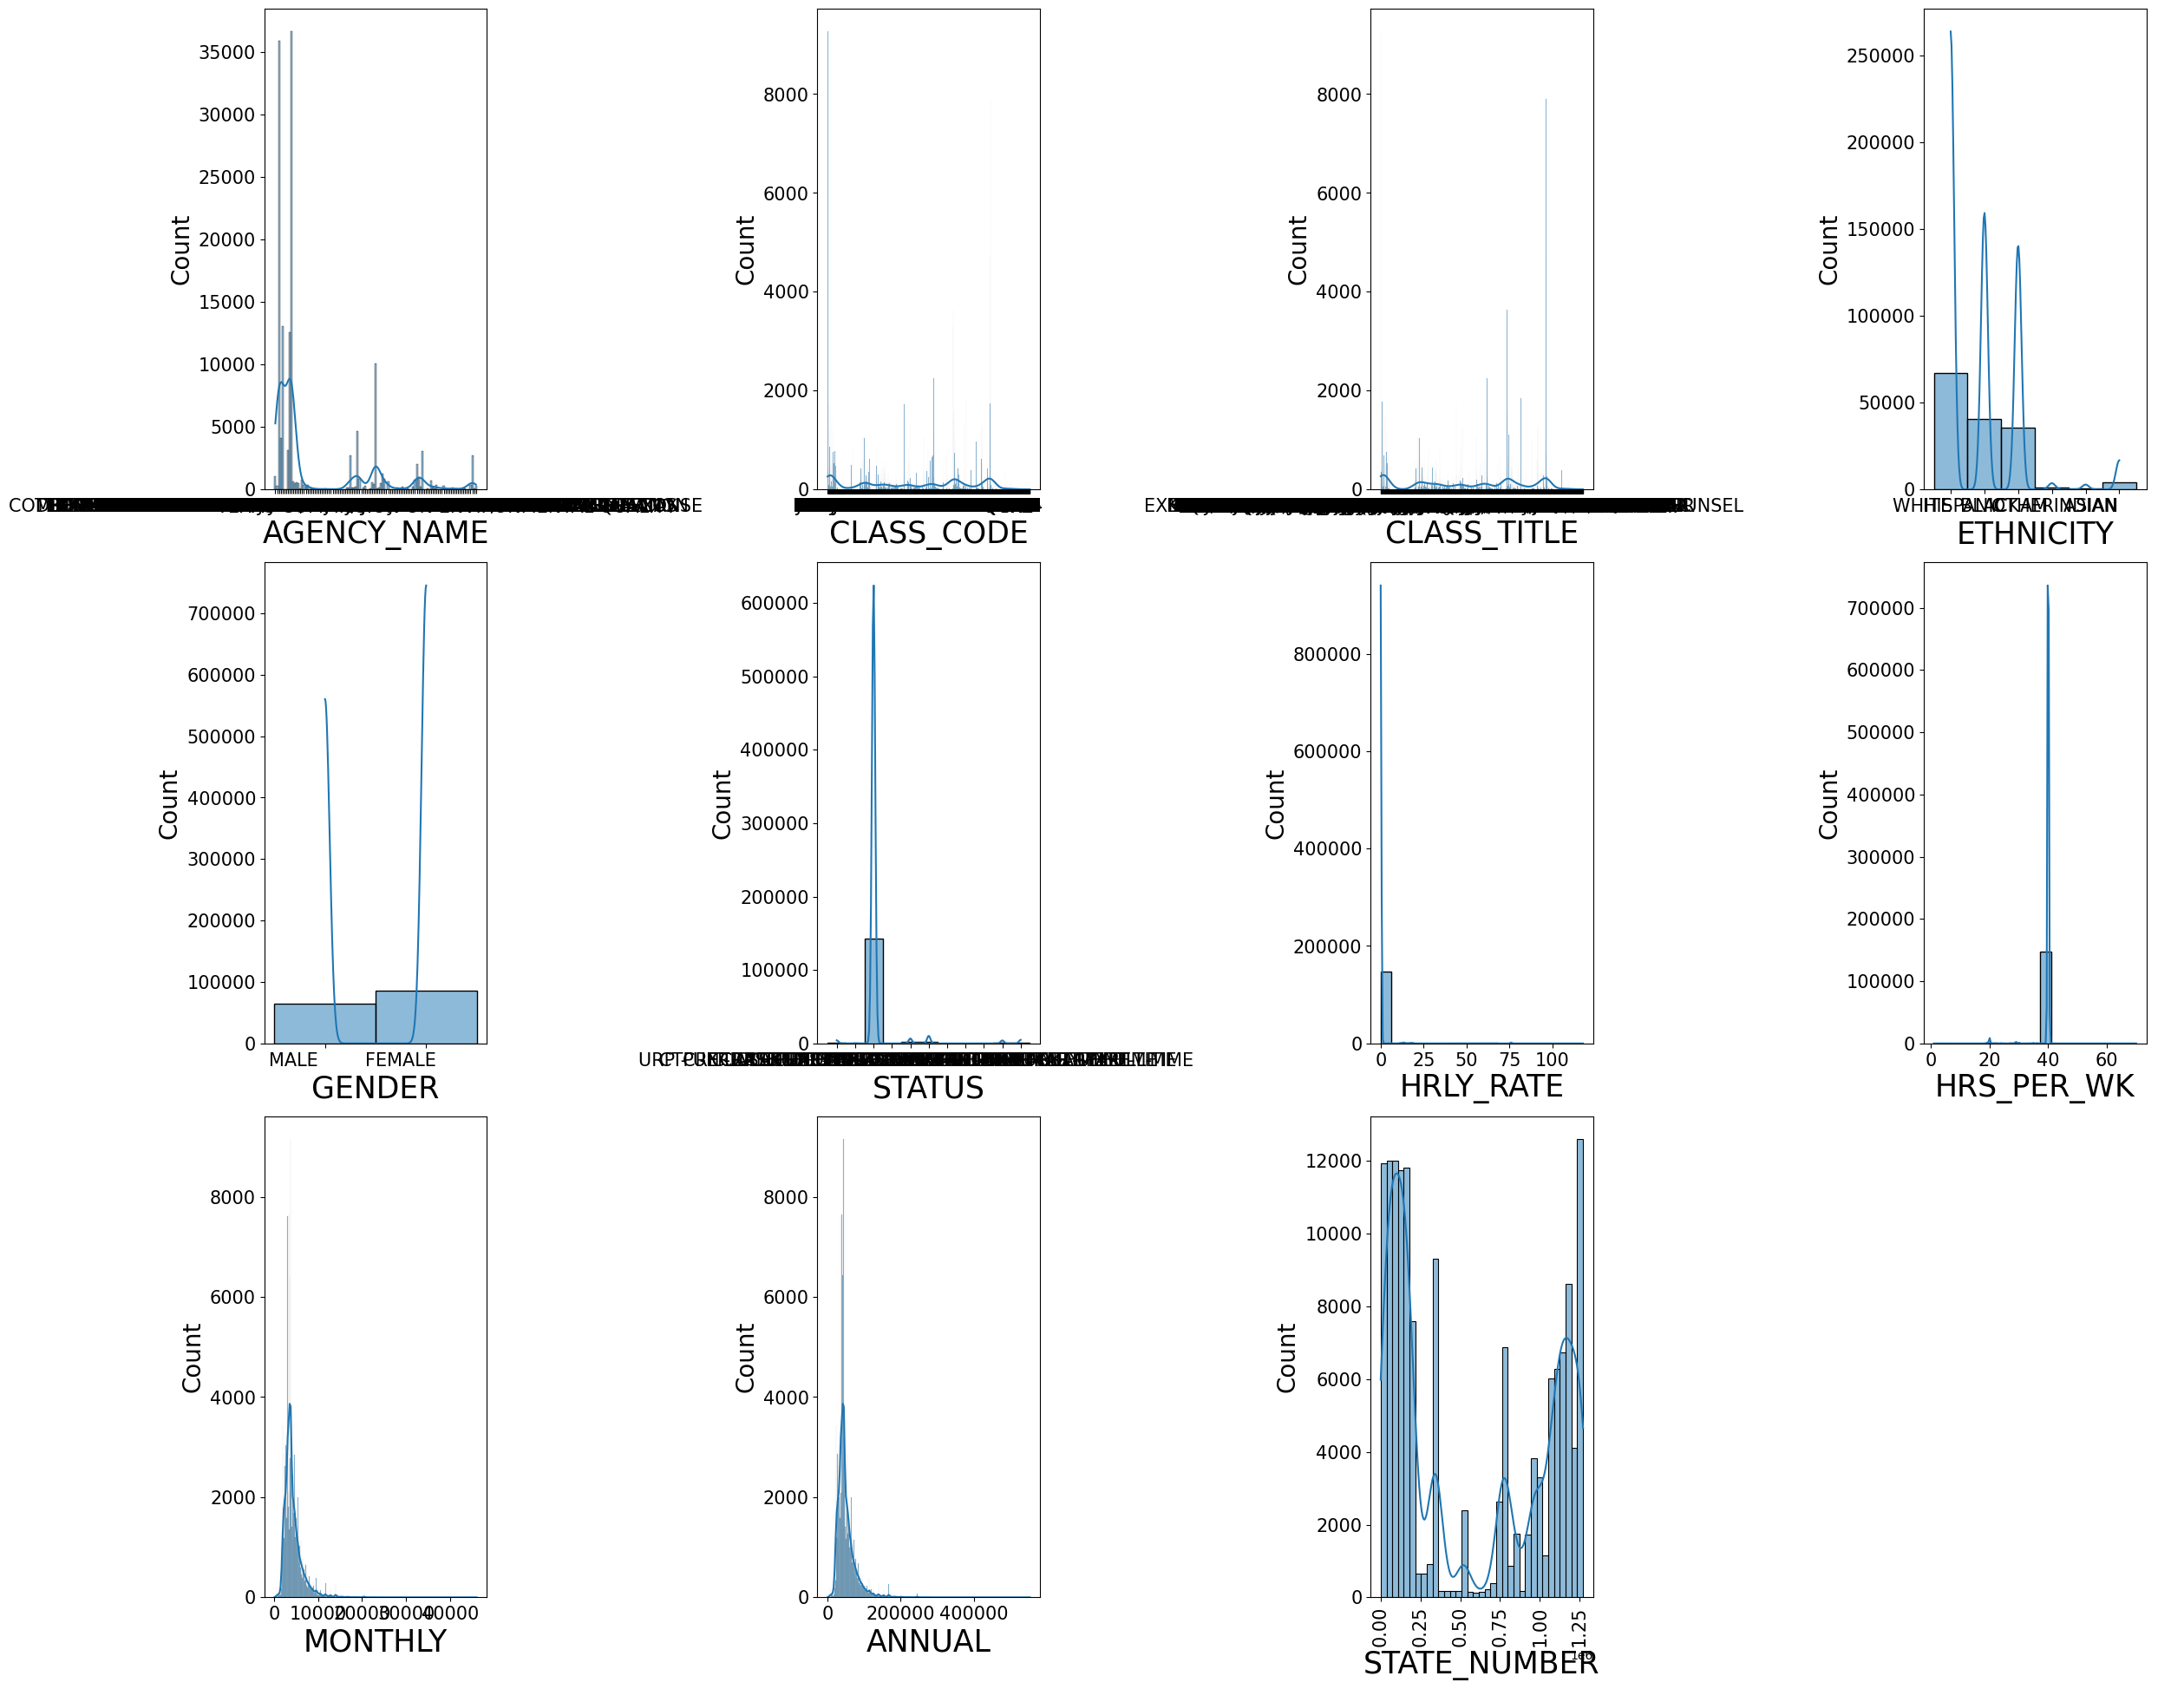

In [59]:
plt.figure(figsize=(25,25))
plot_num = 1

for column in data:
    if plot_num <= 16:
        plt.subplot(4,4,plot_num)
        sns.histplot(data[column],kde=True)
        plt.xlabel(column,fontsize=25)
        plt.ylabel("Count",fontsize=20)
        plt.xticks(fontsize=15)
        plt.yticks(fontsize=15)
    plot_num = plot_num+1
plt.tight_layout()
plt.xticks(rotation = 90)

## 2. Biavariate Analysis :-

<Axes: xlabel='GENDER', ylabel='ANNUAL'>

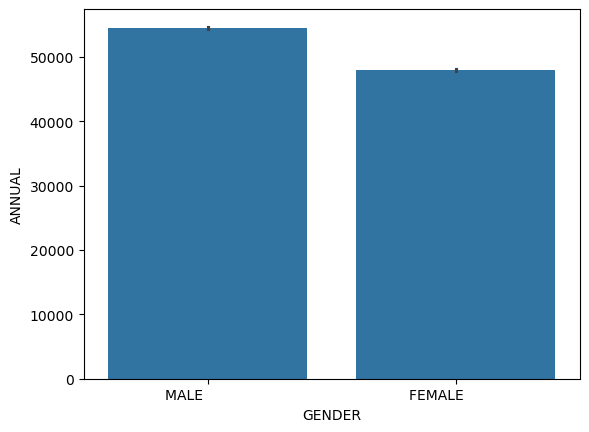

In [60]:
## Aanlyzing the relationship between GENDER and ANNUAL.
sns.barplot(x="GENDER",y="ANNUAL",data=data) # visualize data using seaborn

* By analysis we can say that male have the highest annual income compared to female.

<Axes: xlabel='HRS_PER_WK', ylabel='MONTHLY'>

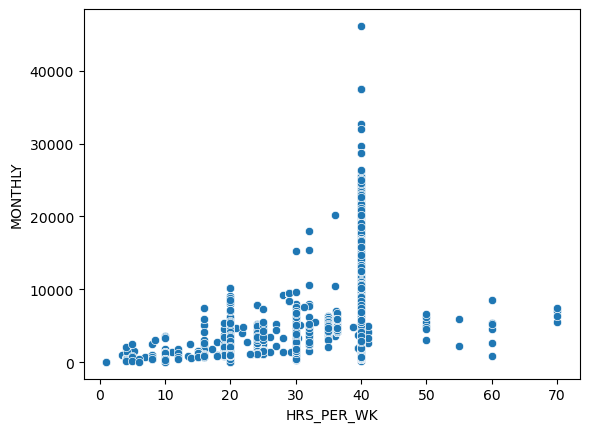

In [61]:
## Aanlyzing the relationship between HRS PER WK and MONTHLY.
sns.scatterplot(x="HRS_PER_WK",y="MONTHLY",data=data) # visualize data using seaborn

* By analysis we can say that monthly income of someone who works 40 hours a week is higher than that of someone who works other hours.

<Axes: xlabel='GENDER', ylabel='MONTHLY'>

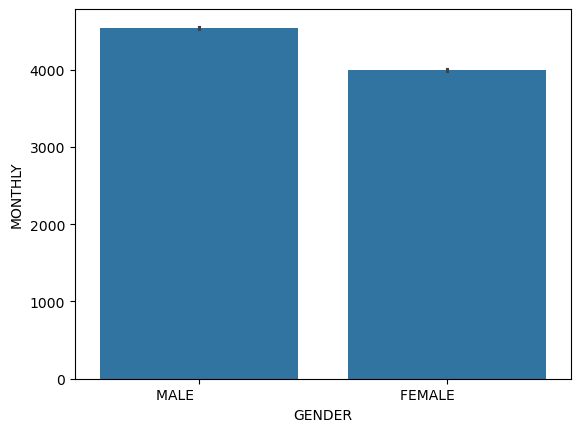

In [62]:
## Aanlyzing the relationship between GENDER and MONTHLY.
sns.barplot(x="GENDER",y="MONTHLY",data=data) # visualize data using seaborn

* By analysis we can say that male have the highest monthly income compared to female.

## 3.  Multivariate Analysis :-

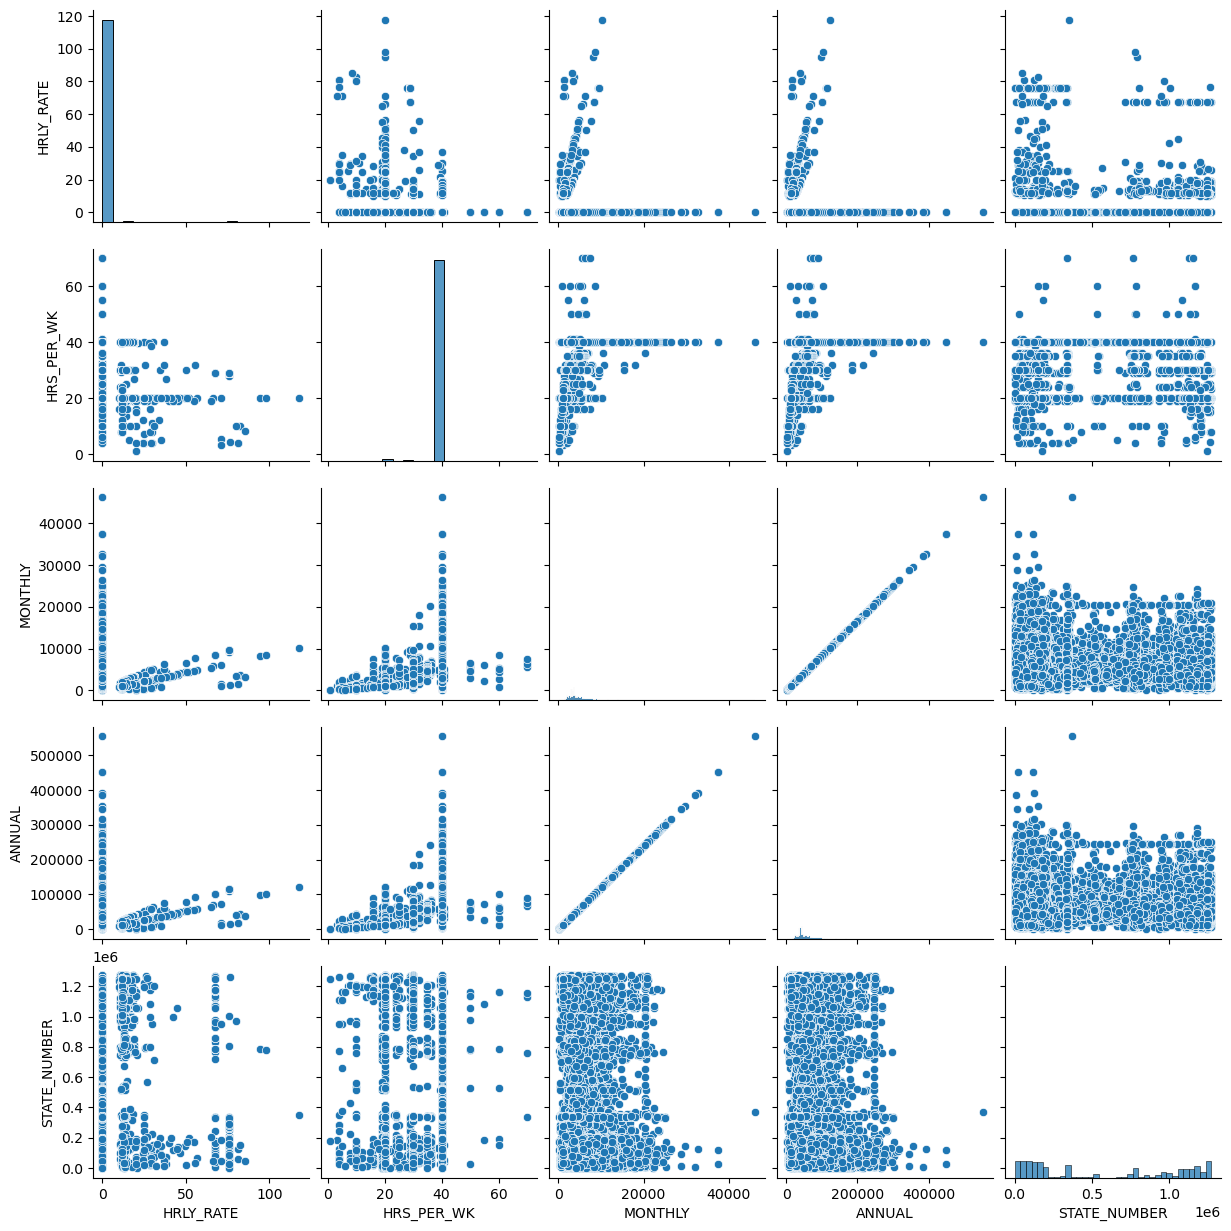

In [63]:
sns.pairplot(data)

## Report Of EDA
* The analysis highlights significant wage disparities, a highly skewed salary distribution, and outliers that influence averages. Departments and roles play a critical role in determining compensation, with part-time and combined jobs often leading to discrepancies.Hourly rates, salaries, and working hours exhibit heavy right-skewed distributions.This EDA provides a foundation for informed decision-making regarding salary policies and resource allocation in Texas agencies.

# Feature Engineering :-

* Feature engineering is an essential step in the data preprocessing process. By leveraging domain knowledge and creativity, you can transform raw data into meaningful features that enhance the performance of machine learning models. Creating new features or modifying existing ones can help the model capture more relevant patterns and relationships, ultimately improving its ability to make accurate predictions.

### 1. Data Preprocessing :-

* Data preprocessing is a foundational step in the machine learning pipeline. It involves cleaning, transforming, and organizing raw data into a format that is suitable for analysis and modeling. Proper data preprocessing ensures that the model performs optimally and provides reliable results. Below is a breakdown of the main steps involved in data preprocessing.
* Handling missing values is an essential aspect of data preprocessing. Missing or incomplete data can lead to biased or inaccurate results, distorting the performance of statistical analyses and machine learning models. Here's a breakdown of why handling missing values is important and how to address them effectively:

In [64]:
data.isnull().sum()

AGENCY_NAME     0
CLASS_CODE      0
CLASS_TITLE     0
ETHNICITY       0
GENDER          0
STATUS          0
HRLY_RATE       0
HRS_PER_WK      0
MONTHLY         0
ANNUAL          0
STATE_NUMBER    0
dtype: int64

* It gives the no null value in dataframe.

* Encoding Categorical Variables : Categorical variables need to be transformed into numerical formats for machine learning models.
  - Label Encoding
  - One-Hot Encoding 
  - Ordinal Encoding

In [65]:
#importing Label from preprocessing
from sklearn.preprocessing import LabelEncoder
label=LabelEncoder()                                # Initialize the LabelEncoder

# Step 1: Filter relevant columns
num_col = ['HRLY_RATE','HRS_PER_WK','STATE_NUMBER','MONTHLY']
features = ['AGENCY_NAME', 'CLASS_TITLE', 'GENDER', 'ETHNICITY','CLASS_CODE']
target = 'ANNUAL'
data_encoded = data[features + [target] + num_col].dropna()

In [66]:
# Step 2: Encode categorical variables
label_encoders = {}
for col in features:
    le = LabelEncoder()
    data_encoded[col] = le.fit_transform(data_encoded[col])
    label_encoders[col] = le

In [67]:
data_encoded

,AGENCY_NAME,CLASS_TITLE,GENDER,ETHNICITY,CLASS_CODE,ANNUAL,HRLY_RATE,HRS_PER_WK,STATE_NUMBER,MONTHLY
0,17,711,1,5,1409,114549.84,75.96150,29.0,127717,9545.82
1,48,560,1,5,616,16857.24,81.04454,4.0,127717,1404.77
2,17,711,1,5,1409,114549.84,75.96150,29.0,59115,9545.82
3,48,560,1,5,616,16857.24,81.04453,4.0,59115,1404.77
4,88,292,0,3,810,39411.24,0.00000,40.0,165030,3284.27
...,...,...,...,...,...,...,...,...,...,...
149476,76,1198,1,5,1042,34788.00,0.00000,40.0,770781,2899.00
149477,76,1404,0,5,84,66000.00,0.00000,40.0,847431,5500.00
149478,76,324,1,5,4,13447.20,12.93000,20.0,34266,1120.60
149479,76,1007,1,5,278,68929.92,0.00000,40.0,123490,5744.16


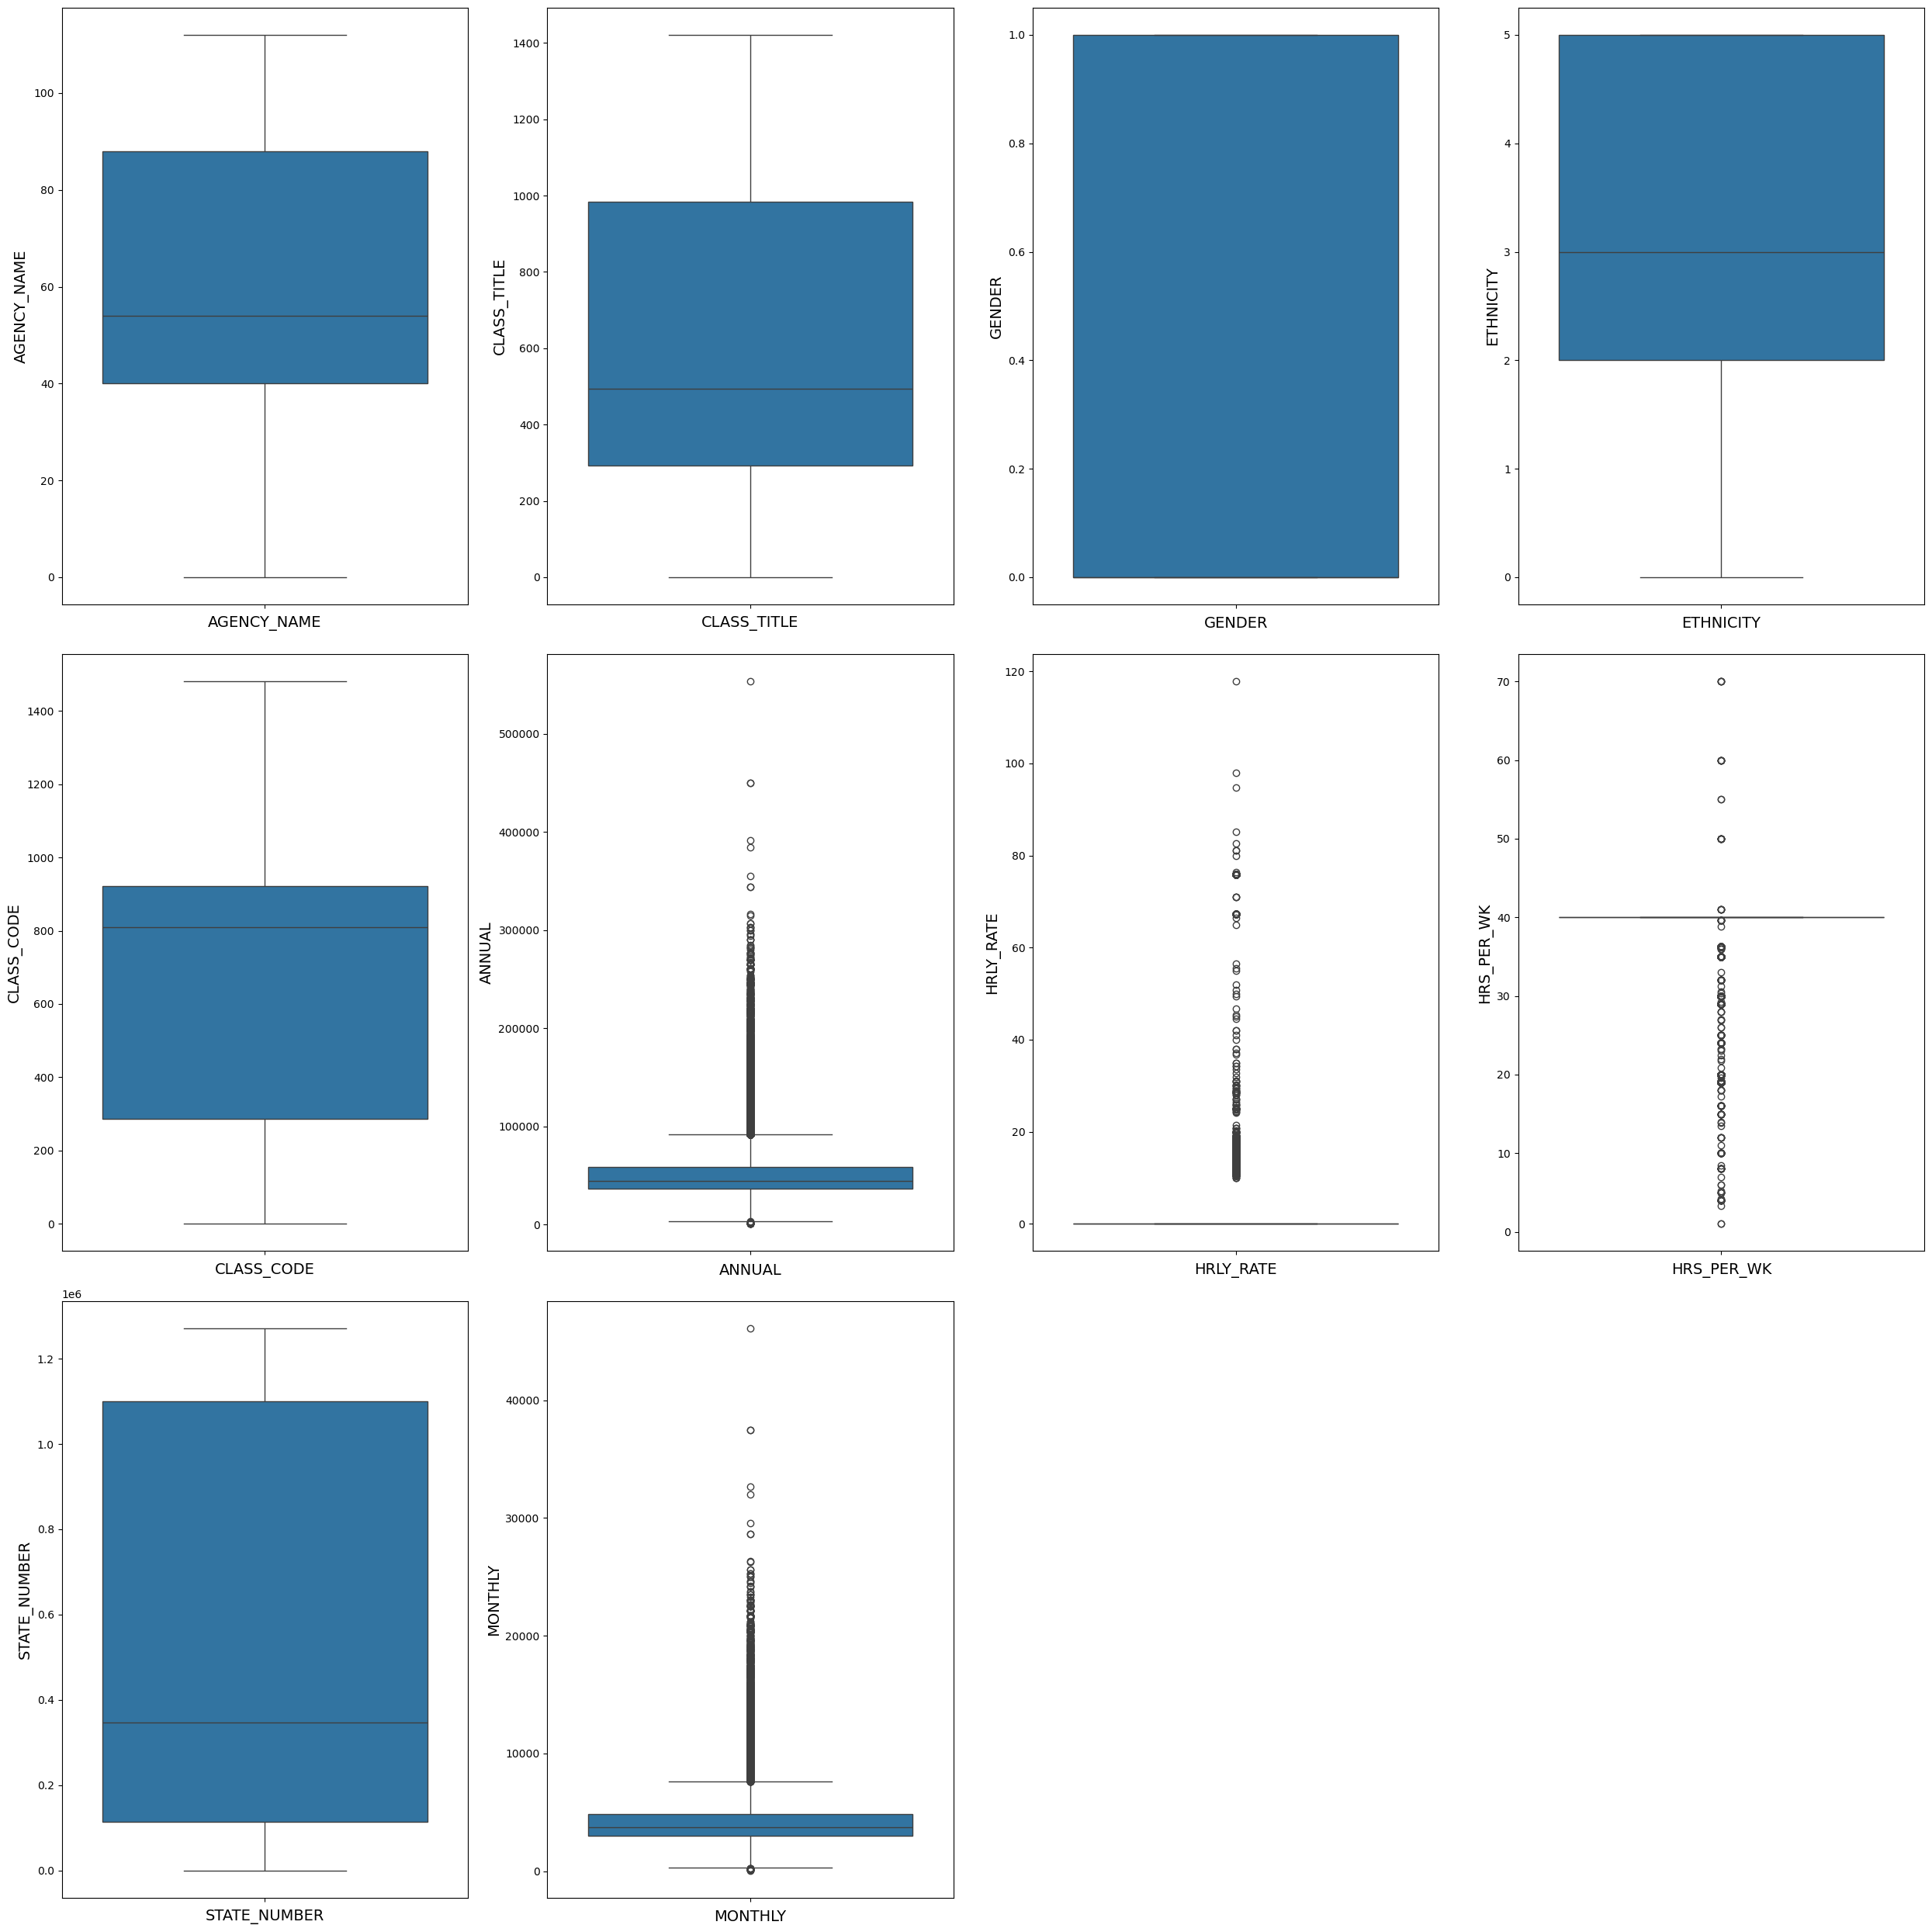

In [68]:
#checking outliers
plt.figure(figsize=(25,25))    #define a figure size # visualize data using matplotlib
plot_num=1
for i in data_encoded.columns:
        plt.subplot(3,4,plot_num)                #create rows and column grid in 4x4 # visualize data using matplotlib
        sns.boxplot(data_encoded[i])                 # Create boxplot using of check outliers # visualize data using seaborn
        plt.xlabel(i,fontsize=14)            # X-axis label # visualize data using matplotlib
        plt.ylabel(i,fontsize=14)            # Y-axis label # visualize data using matplotlib
        plot_num+=1
plt.tight_layout()     # show the data # visualize data using matplotlib

<Axes: ylabel='MONTHLY'>

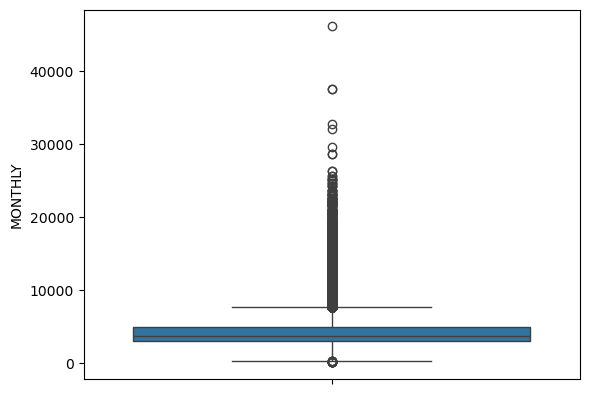

In [69]:
sns.boxplot(data.MONTHLY)

In [70]:
q1 = data.MONTHLY.quantile(0.25)
q3 = data.MONTHLY.quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5*iqr
upper = q3 + 1.5*iqr

In [71]:
data.loc[(data['MONTHLY'] < lower) | (data['MONTHLY'] > upper), 'MONTHLY']

0          9545.82
2          9545.82
5         12899.00
7         10000.00
36         8000.00
            ...   
149374    10583.34
149393     8358.41
149401     7916.67
149415    10188.09
149475    14665.83
Name: MONTHLY, Length: 9031, dtype: float64

In [72]:
data.loc[(data['MONTHLY'] < lower) | (data['MONTHLY'] > upper), 'MONTHLY'] = data.MONTHLY.median()

<Axes: ylabel='MONTHLY'>

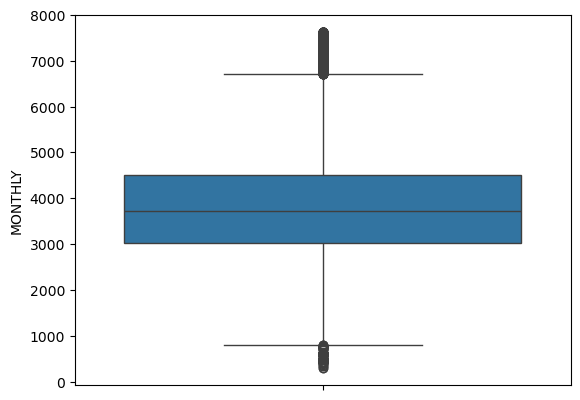

In [73]:
sns.boxplot(data.MONTHLY)

### 2. Feature Selection :-

* Feature selection : is a critical step in the data preprocessing pipeline, where the goal is to select the most important features from the original set of features in a dataset. By choosing only the relevant features, we aim to improve the performance of machine learning models. This process can help reduce complexity, improve model accuracy, and speed up the training process.

In [74]:
data_encoded.corr()  #check corrlation

,AGENCY_NAME,CLASS_TITLE,GENDER,ETHNICITY,CLASS_CODE,ANNUAL,HRLY_RATE,HRS_PER_WK,STATE_NUMBER,MONTHLY
AGENCY_NAME,1.000000,-0.150526,0.190787,0.030906,-0.052702,-0.085757,-0.054441,-0.012687,0.021148,-0.085757
CLASS_TITLE,-0.150526,1.000000,0.060309,0.044255,0.144373,0.085747,0.014504,0.011968,-0.092181,0.085747
GENDER,0.190787,0.060309,1.000000,0.106739,0.127360,0.129265,0.041537,0.001952,-0.003143,0.129265
ETHNICITY,0.030906,0.044255,0.106739,1.000000,-0.056818,0.170107,0.051916,-0.023782,-0.074631,0.170107
CLASS_CODE,-0.052702,0.144373,0.127360,-0.056818,1.000000,-0.074360,0.091614,-0.068355,0.047658,-0.074360
ANNUAL,-0.085757,0.085747,0.129265,0.170107,-0.074360,1.000000,0.086291,0.096041,-0.265438,1.000000
HRLY_RATE,-0.054441,0.014504,0.041537,0.051916,0.091614,0.086291,1.000000,-0.337784,-0.007922,0.086291
HRS_PER_WK,-0.012687,0.011968,0.001952,-0.023782,-0.068355,0.096041,-0.337784,1.000000,-0.010072,0.096041
STATE_NUMBER,0.021148,-0.092181,-0.003143,-0.074631,0.047658,-0.265438,-0.007922,-0.010072,1.000000,-0.265438
MONTHLY,-0.085757,0.085747,0.129265,0.170107,-0.074360,1.000000,0.086291,0.096041,-0.265438,1.000000


<Axes: >

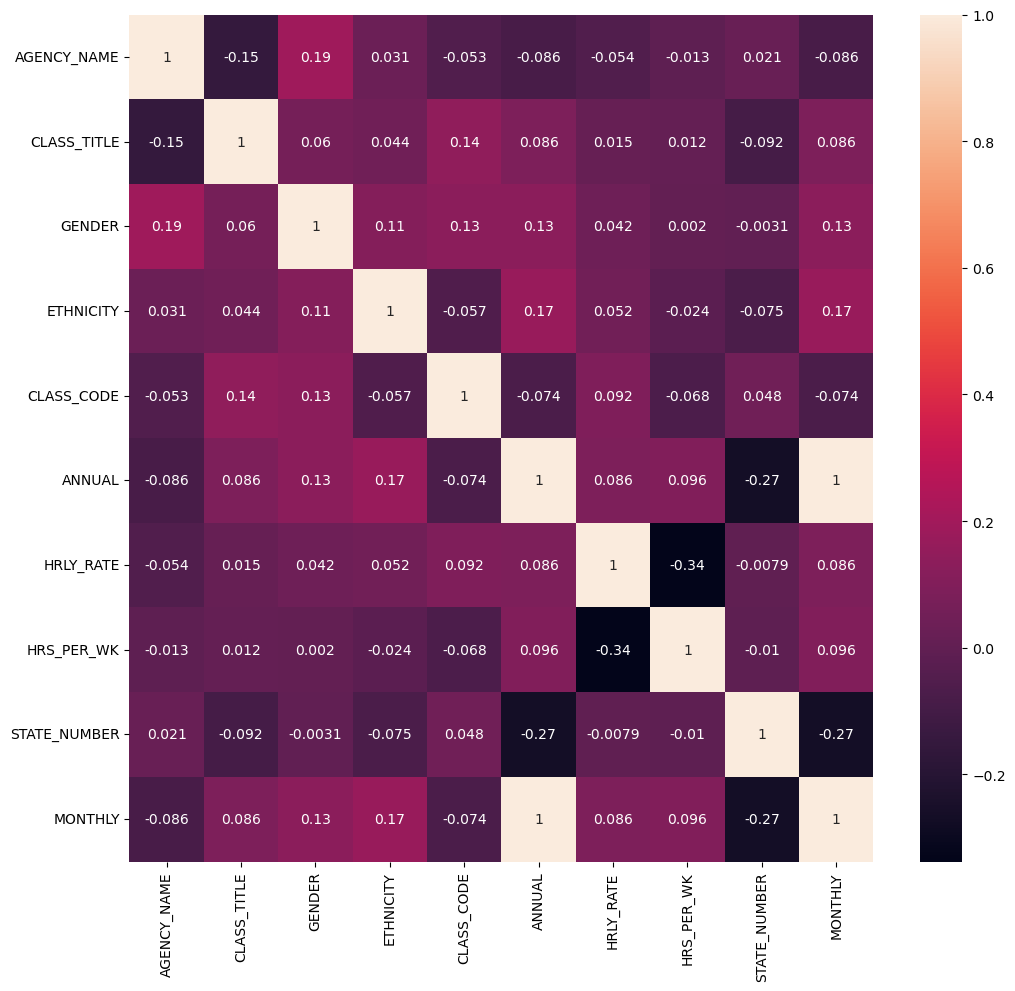

In [75]:
## We have check correlation
plt.figure(figsize=(12,11))                                #increase plot size # visualize data using matplotlib
sns.heatmap(data_encoded.corr(),annot_kws={'size':10},annot=True)  # craete a heatmap check the relationship # visualize data using seaborn

# Model Creation :-

In [76]:
## Creating independent and dependent variable
X = data_encoded.drop(["ANNUAL"],axis=1)
y = data_encoded.ANNUAL

* Scaling : is an essential technique in the data preprocessing stage, particularly for continuous features.Scaling helps to standardize the range of features, making them comparable and improving model performance.

* It is technique to convert all data into certain range.

#### The types of scalling are :

* Min-Max Scaling : Min-Max scaling transforms the data to a specific range, usually between 0 and 1. The values are rescaled according to the minimum and maximum values of the feature.
* Standardization : - Standardization Scaling transform all data between -3 to +3 range. it use z-score to tranform data.

In [77]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [78]:
X_scaled

array([[ -1.50007103,   0.21516168,   1.15328674, ...,  -4.61085373,
         -0.91403696,   2.54150487],
       [ -0.42552661,  -0.1583747 ,   1.15328674, ..., -15.36887767,
         -0.91403696,  -1.34795658],
       [ -1.50007103,   0.21516168,   1.15328674, ...,  -4.61085373,
         -1.05736999,   2.54150487],
       ...,
       [  0.54502965,  -0.74217991,   1.15328674, ...,  -8.48374235,
         -1.10928805,  -1.48372141],
       [  0.54502965,   0.94739194,   1.15328674, ...,   0.12267681,
         -0.92286861,   0.72522687],
       [  0.54502965,  -0.74217991,  -0.86708705, ...,  -8.48374235,
         -0.96446114,  -1.5329975 ]])

In [81]:
X_scaled = data[["HRLY_RATE","HRS_PER_WK","STATE_NUMBER","MONTHLY"]]
X_scaled = scaler.fit_transform(X_scaled)

In [82]:
X_scaled

array([[ 17.95453763,  -4.61085373,  -0.91403696,  -0.09174811],
       [ 19.16148888, -15.36887767,  -0.91403696,  -1.92747175],
       [ 17.95453763,  -4.61085373,  -1.05736999,  -0.09174811],
       ...,
       [  2.98791386,  -8.48374235,  -1.10928805,  -2.15277087],
       [ -0.0822724 ,   0.12267681,  -0.92286861,   1.5129363 ],
       [  2.70535225,  -8.48374235,  -0.96446114,  -2.23454358]])

In [87]:
X_scaled_data = pd.DataFrame(X_scaled, columns=[["HRLY_RATE","HRS_PER_WK","STATE_NUMBER","MONTHLY"]])

In [88]:
X_scaled_data

,HRLY_RATE,HRS_PER_WK,STATE_NUMBER,MONTHLY
0,17.954538,-4.610854,-0.914037,-0.091748
1,19.161489,-15.368878,-0.914037,-1.927472
2,17.954538,-4.610854,-1.057370,-0.091748
3,19.161487,-15.368878,-1.057370,-1.927472
4,-0.082272,0.122677,-0.836077,-0.437344
...,...,...,...,...
149476,-0.082272,0.122677,0.429544,-0.742798
149477,-0.082272,0.122677,0.589692,1.319358
149478,2.987914,-8.483742,-1.109288,-2.152771
149479,-0.082272,0.122677,-0.922869,1.512936


In [89]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=4)

In [90]:
X_train

,AGENCY_NAME,CLASS_TITLE,GENDER,ETHNICITY,CLASS_CODE,HRLY_RATE,HRS_PER_WK,STATE_NUMBER,MONTHLY
124815,88,292,1,2,810,0.0,40.0,1253912,3284.27
20383,28,1226,0,2,1215,0.0,40.0,71446,7207.91
145145,5,236,1,5,3,0.0,40.0,1119702,2639.00
136477,92,1300,1,1,58,0.0,40.0,101342,9558.04
95275,91,484,1,5,1146,0.0,40.0,127656,3715.60
...,...,...,...,...,...,...,...,...,...
115144,88,292,0,3,810,0.0,20.0,162690,1602.09
142935,95,491,0,5,14,0.0,40.0,291165,3200.00
129384,88,293,0,5,811,0.0,40.0,119557,3720.17
120705,88,599,0,2,1003,0.0,40.0,767592,3006.41


In [91]:
y_train

124815     39411.24
20383      86494.92
145145     31668.00
136477    114696.48
95275      44587.20
            ...    
115144     19225.08
142935     38400.00
129384     44642.04
120705     36076.92
115397     46073.40
Name: ANNUAL, Length: 119584, dtype: float64

# Model Selection :-

In [92]:
# Importing the LinearRegression model from scikit-learn
from sklearn.linear_model import LinearRegression

# Creating an instance (object) of the LinearRegression model
LR = LinearRegression()

# Training (fitting) the Linear Regression model using the training data
# The model will learn the relationship between the features (x_train) and the target variable (y_train)
LR.fit(X_train, y_train)

LinearRegression()

In [93]:
# Making predictions on the training data using the trained Linear Regression model
# The model will use the learned coefficients to predict the target variable based on x_train features

y_predict = LR.predict(X_train)

In [94]:
# Making predictions on the testing data using the trained Linear Regression model
# The model will use the learned coefficients to predict the target variable based on x_test features

y_pred = LR.predict(X_test)

In [95]:
y_predict

array([39411.24, 86494.92, 31668.  , ..., 44642.04, 36076.92, 46073.4 ])

#### Evalution of Model :

In [96]:
from sklearn.metrics import mean_squared_error,root_mean_squared_error,mean_absolute_error,r2_score

In [97]:
mean_squared_error(y_train,y_predict)

3.064289823776282e-19

In [98]:
mean_squared_error(y_test,y_pred)

3.0902422183595084e-19

In [99]:
root_mean_squared_error(y_train,y_predict)

5.535602789016099e-10

In [100]:
root_mean_squared_error(y_test,y_pred)

5.558994709800963e-10

In [101]:
mean_absolute_error(y_train,y_predict)

5.253958089213409e-10

In [102]:
mean_absolute_error(y_test,y_pred)

5.279730784272943e-10

In [103]:
r2_score(y_train,y_predict)

1.0

In [104]:
r2_score(y_test,y_pred)

1.0

## 2. DecisionTree

In [105]:
# Import the DecisionTreeClassifier from scikit-learn's tree module
from sklearn.tree import DecisionTreeRegressor

# Create an instance of the DecisionTreeClassifier with default parameters
dt = DecisionTreeRegressor()

# Fit (train) the decision tree classifier using the training data
# x_train: feature variables, y_train: target variable
dt.fit(X_train, y_train)

DecisionTreeRegressor()

In [106]:
y_predict = dt.predict(X_train) #predicting the model

In [107]:
y_pred = dt.predict(X_test)  # predicting the model

In [108]:
mean_squared_error(y_train,y_predict)

2.408348943112404e-07

In [109]:
mean_squared_error(y_test,y_pred)

84114.75573147812

In [110]:
r2_score(y_train,y_predict)

0.9999999999999997

In [111]:
r2_score(y_test,y_pred)

0.9998664961735461

## 3. RandomForestRegressor

In [112]:
from sklearn.ensemble import RandomForestRegressor   #importing randomforest
rfc = RandomForestRegressor()                     #object creation for random forest
rfc.fit(X_train,y_train)                             # training the data

RandomForestRegressor()

In [113]:
y_predict = rfc.predict(X_train)  # predicting the model

In [114]:
y_pred = rfc.predict(X_test)  # predicting the model

In [115]:
mean_squared_error(y_train,y_predict)

35876.14966692203

In [116]:
mean_squared_error(y_test,y_pred)

64180.81940324393

In [117]:
r2_score(y_train,y_predict)

0.9999431486490152

In [118]:
r2_score(y_test,y_pred)

0.9998981345793521

## 4. KNN

In [119]:
from sklearn.neighbors import KNeighborsRegressor     #importing the model library
knn = KNeighborsRegressor()                            # object creation
knn.fit(X_train, y_train)                              # fillting the data

KNeighborsRegressor()

In [120]:
y_predict = knn.predict(X_train)  # predicting the model

In [121]:
y_pred = knn.predict(X_test)  # predicting the model

In [122]:
mean_squared_error(y_train,y_predict)

5872554.064409665

In [123]:
mean_squared_error(y_test,y_pred)

10293628.202876467

In [124]:
r2_score(y_train,y_predict)

0.9906940227590643

In [125]:
r2_score(y_test,y_pred)

0.9836623343760785

## 5. XtremeGradientBoosting

In [126]:
# Import the XGBRegressor class from the xgboost library
from xgboost import XGBRegressor

# Create an instance of the XGBRegressor model (used for regression tasks)
XGBoost = XGBRegressor()

# Train (fit) the XGBoost model using the training features (X_train) and target values (y_train)
XGBoost.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [127]:
y_predict = XGBoost.predict(X_train)  # predicting the model

In [128]:
y_pred = XGBoost.predict(X_test)  # predicting the model

In [129]:
mean_squared_error(y_train,y_predict)

420562.14774808165

In [130]:
mean_squared_error(y_test,y_pred)

4652765.63262978

In [131]:
r2_score(y_train,y_predict)

0.9993335537259569

In [132]:
r2_score(y_test,y_pred)

0.9926153026285585

In [133]:
models= pd.DataFrame({
    "Models" : ["LinearRegression","DecisionTree","RandomForestRegressor","KNN","XtremeGradientBoosting"],
    "training r2 score":[1.0,0.9999999999999997,0.9999723820228837,0.9906940227590643,0.9993335537259569],
    "testing r2 score":[1.0,0.9999806660051156,0.9999223308161258,0.9836623343760785,0.9926153026285585]
})

In [134]:
models

,Models,training r2 score,testing r2 score
0,LinearRegression,1.000000,1.000000
1,DecisionTree,1.000000,0.999981
2,RandomForestRegressor,0.999972,0.999922
3,KNN,0.990694,0.983662
4,XtremeGradientBoosting,0.999334,0.992615


## Model Comparision Report
* I have used total 5 Algorithm like LinearRegression, DecisionTree, RandomForestRegressor,KNN, XtremeGradientBoosting.
* Best Model: LinearRegression achieves the highest R² score 100 % suggesting it perfectly explains the variance in payroll data.
* DecisionTree, RandomForestRegressor & XtremeGradientBoosting an R² score of 99.99%, 99.99%, 99.26% near 100%
* KNN achieving an R² score of 98.36%

## Final Report
* I have implemented 5 algorithms in analysis, which include LinearRegression, DecisionTree, RandomForestRegressor, KNN, XtremeGradientBoosting.
* I have calculated the R² score, Mean Absolute Error (MAE), and R2 Score to evaluate the performance of the best models.
* LinearRegression model has shown outstanding performance R² score of 100.00%.
* DecisionTree, RandomForestRegressor & XtremeGradientBoosting an R² score of 99.99%, 99.99%, 99.26% 
* KNN achieving an R² score of 98.36%

In [135]:
import pickle                             #Importing the pickle module

In [136]:
with open('models.pkl', 'wb') as file:
    pickle.dump(models, file)

In [137]:
with open("models.pkl","rb") as f:   #Open the file "best_model.pkl" in read-binary mode
  models=pickle.load(f)